In [1]:
import subprocess, sys
for pkg in ['torch', 'torchvision', 'scikit-learn', 'matplotlib', 'seaborn', 'gradio']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg], capture_output=True)
print('All packages ready!')

All packages ready!


In [3]:
import os, random, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler  # ← added here
from torchvision import datasets, transforms, models
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42); random.seed(42); np.random.seed(42)
print('Device:', DEVICE)

Device: cpu


In [5]:
BASE       = os.getcwd()
TRAIN_PATH = os.path.join(BASE, 'archive_extracted', 'Training')
TEST_PATH  = os.path.join(BASE, 'archive_extracted', 'Testing')

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 4
EPOCHS      = 30
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print('Train exists:', os.path.exists(TRAIN_PATH))
print('Test  exists:', os.path.exists(TEST_PATH))

Train exists: True
Test  exists: True


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    # Simulate different MRI contrast levels
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    # Blur to simulate scan noise
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    # Randomly erase small patches — forces model to not rely on single region
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print('Transforms defined.')

Transforms defined.


In [9]:
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
test_dataset  = datasets.ImageFolder(TEST_PATH,  transform=test_transform)

# Count samples per class
class_counts = np.bincount(train_dataset.targets)
print('Samples per class:', dict(zip(CLASS_NAMES, class_counts)))

# Give higher weight to underrepresented classes
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_dataset.targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_dataset)} images  |  Test: {len(test_dataset)} images')

Samples per class: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
Train: 5600 images  |  Test: 1600 images


In [11]:
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Freeze entire backbone first
for param in mobilenet.features.parameters():
    param.requires_grad = False

# Unfreeze last 3 feature blocks for fine-tuning
for layer in mobilenet.features[-3:]:
    for param in layer.parameters():
        param.requires_grad = True

# Replace classifier with a stronger head
in_features = mobilenet.classifier[1].in_features
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, NUM_CLASSES),
)

trainable = sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in mobilenet.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')

Trainable params: 1,995,332 / 3,013,124


In [13]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader.dataset), correct / len(loader.dataset), all_preds, all_labels

print('Helpers ready!')

Helpers ready!


In [15]:
model = mobilenet.to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing reduces overconfidence
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history  = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0
best_wts = copy.deepcopy(model.state_dict())
patience, no_improve = 7, 0   # early stopping: stop if no improvement for 7 epochs

print('--- Training Improved MobileNetV2 ---')
for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc       = train_one_epoch(model, train_loader, criterion, optimizer)
    v_loss, v_acc, _, _ = evaluate(model, test_loader, criterion)
    scheduler.step()

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    if v_acc > best_acc:
        best_acc = v_acc
        best_wts = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    print(f'  Epoch {epoch:02d}/{EPOCHS}  '
          f'Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  '
          f'Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}'
          + ('  best' if no_improve == 0 else ''))

    if no_improve >= patience:
        print(f'  Early stopping at epoch {epoch}')
        break

model.load_state_dict(best_wts)
torch.save(model.state_dict(), 'model3_improved.pth')
print(f'\n Best Val Accuracy: {best_acc:.4f}  — saved as model3_improved.pth')

--- Training Improved MobileNetV2 ---
  Epoch 01/30  Train Loss: 0.8052  Train Acc: 0.7762  Val Loss: 0.7260  Val Acc: 0.8181  best
  Epoch 02/30  Train Loss: 0.6131  Train Acc: 0.8741  Val Loss: 0.7014  Val Acc: 0.8281  best
  Epoch 03/30  Train Loss: 0.5708  Train Acc: 0.8936  Val Loss: 0.6492  Val Acc: 0.8700  best
  Epoch 04/30  Train Loss: 0.5424  Train Acc: 0.9114  Val Loss: 0.6360  Val Acc: 0.8744  best
  Epoch 05/30  Train Loss: 0.5440  Train Acc: 0.9007  Val Loss: 0.6270  Val Acc: 0.8794  best
  Epoch 06/30  Train Loss: 0.5055  Train Acc: 0.9275  Val Loss: 0.6309  Val Acc: 0.8800  best
  Epoch 07/30  Train Loss: 0.5067  Train Acc: 0.9236  Val Loss: 0.6400  Val Acc: 0.8744
  Epoch 08/30  Train Loss: 0.4907  Train Acc: 0.9304  Val Loss: 0.5852  Val Acc: 0.9012  best
  Epoch 09/30  Train Loss: 0.4855  Train Acc: 0.9329  Val Loss: 0.5735  Val Acc: 0.9044  best
  Epoch 10/30  Train Loss: 0.4738  Train Acc: 0.9411  Val Loss: 0.5648  Val Acc: 0.9069  best
  Epoch 14/30  Train Loss: 0

In [17]:
_, acc, preds, labels = evaluate(model, test_loader, criterion)
prec = precision_score(labels, preds, average='weighted', zero_division=0)
rec  = recall_score(   labels, preds, average='weighted', zero_division=0)
f1   = f1_score(       labels, preds, average='weighted', zero_division=0)

print(f'Test Accuracy : {acc:.4f}')
print(f'Precision     : {prec:.4f}')
print(f'Recall        : {rec:.4f}')
print(f'F1 Score      : {f1:.4f}')

Test Accuracy : 0.9313
Precision     : 0.9345
Recall        : 0.9313
F1 Score      : 0.9295


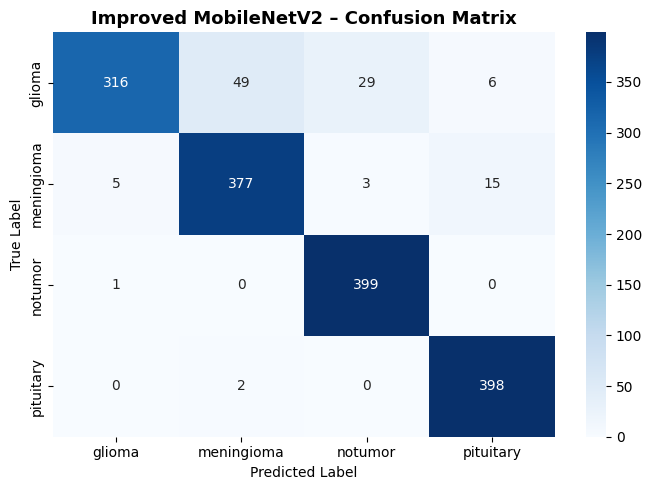

In [18]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Improved MobileNetV2 – Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('model3_improved_confusion.png')
plt.show()

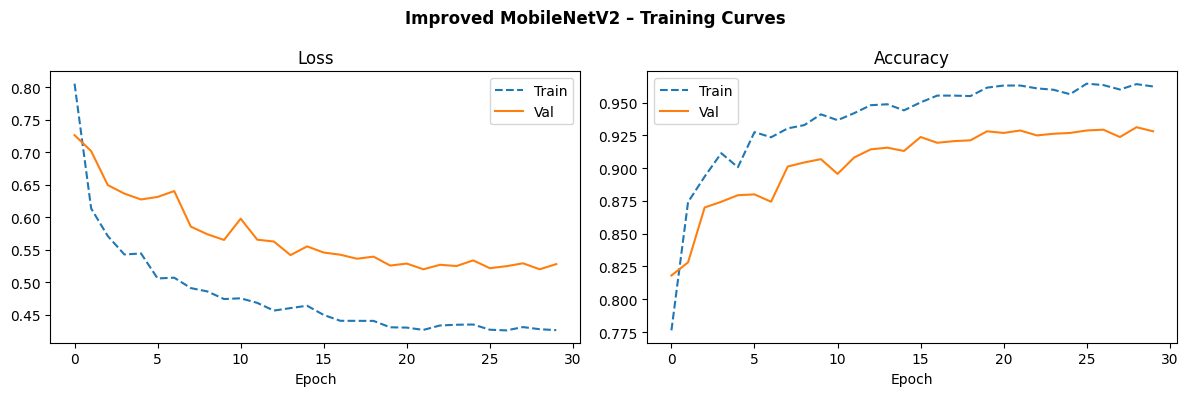

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], '--', label='Train'); axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['train_acc'], '--', label='Train'); axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle('Improved MobileNetV2 – Training Curves', fontweight='bold')
plt.tight_layout(); plt.savefig('model3_improved_curves.png'); plt.show()

In [20]:
print(classification_report(labels, preds, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

      glioma       0.98      0.79      0.88       400
  meningioma       0.88      0.94      0.91       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.95      0.99      0.97       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



In [25]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'gradio'], capture_output=True)
import gradio as gr

model.eval()

ui_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def predict(image):
    img_tensor = ui_transform(image.convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(img_tensor)
        probs  = torch.softmax(output, dim=1).squeeze().cpu().numpy()
    return {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)}

demo = gr.Interface(
    fn          = predict,
    inputs      = gr.Image(type='pil', label='Upload Brain MRI Image'),
    outputs     = gr.Label(num_top_classes=4, label='Prediction'),
    title       = '🧠 Brain Tumor Classifier (Improved)',
    description = 'Upload a brain MRI. Classifies: Glioma | Meningioma | No Tumor | Pituitary',
    flagging_mode = 'never',
)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://57aba08fcaf2a716fd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
